## Loading the Libraries and Dataset

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


sns.set(style="whitegrid")

import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv( 'bpl_24_25.csv')

df.head()

,season,match_no,date,team_1,team_1_score,team_1_wicket,team_2,team_2_score,team_2_wicket,player_of_match,toss_winner,toss_decision,winner,venue,city,win_by_wickets,win_by_runs,result,umpire_1,umpire_2
0,2024/25,1st,Dec 30 2024,Durbar Rajshahi,197,3,Fortune Barishal,200,6,Mahmudullah,Fortune Barishal,field first,Fortune Barishal,SBNCS,Mirpur,4,0,4 wickets,Asif Yaqoob,Masudur Rahman
1,2024/25,2nd,Dec 30 2024,Rangpur Riders,196,6,Dhaka Capital,151,9,Khushdil Shah,Dhaka Capital,field first,Rangpur Riders,SBNCS,Mirpur,0,40,40 runs,Mahfuzur Rahman,RR Wimalasiri
2,2024/25,3rd,Dec 31 2024,Khulna Tigers,203,4,Chittagong Kings,166,10,Mahidul Islam Ankon,Chittagong Kings,field first,Khulna Tigers,SBNCS,Mirpur,0,37,37 runs,Tanvir Ahmed,RR Wimalasiri
3,2024/25,4th,Dec 31 2024,Rangpur Riders,155,6,Sylhet Strikers,121,9,Nahid Rana,Rangpur Riders,bat first,Rangpur Riders,SBNCS,Mirpur,0,34,34 runs,Asif Yaqoob,Gazi Sohel
4,2024/25,5th,Jan 2 2025,Dhaka Capital,174,9,Durbar Rajshahi,179,3,Taskin Ahmed,Dhaka Capital,bat first,Durbar Rajshahi,SBNCS,Mirpur,7,0,7 wickets,Mahfuzur Rahman,RR Wimalasiri


## Basic Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   season           46 non-null     object
 1   match_no         46 non-null     object
 2   date             46 non-null     object
 3   team_1           46 non-null     object
 4   team_1_score     46 non-null     int64 
 5   team_1_wicket    46 non-null     int64 
 6   team_2           46 non-null     object
 7   team_2_score     46 non-null     int64 
 8   team_2_wicket    46 non-null     int64 
 9   player_of_match  46 non-null     object
 10  toss_winner      46 non-null     object
 11  toss_decision    46 non-null     object
 12  winner           46 non-null     object
 13  venue            46 non-null     object
 14  city             46 non-null     object
 15  win_by_wickets   46 non-null     int64 
 16  win_by_runs      46 non-null     int64 
 17  result           46 non-null     obje

In [4]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 46 and your columns are 20


In [5]:
df.isnull().sum()

season             0
match_no           0
date               0
team_1             0
team_1_score       0
team_1_wicket      0
team_2             0
team_2_score       0
team_2_wicket      0
player_of_match    0
toss_winner        0
toss_decision      0
winner             0
venue              0
city               0
win_by_wickets     0
win_by_runs        0
result             0
umpire_1           0
umpire_2           0
dtype: int64

## Basic Match Analysis

**1 Total matches per season**

In [6]:
matches_per_season = df.groupby('season').size().reset_index(name='total_matches')

print(matches_per_season)

    season  total_matches
0  2024/25             46


**2.Team-wise Total Matches**

In [7]:
# Count matches played as team_1
team1_matches = df['team_1'].value_counts()

# Count matches played as team_2
team2_matches = df['team_2'].value_counts()

# Combine both counts
total_matches = team1_matches.add(team2_matches, fill_value=0)

# Convert to DataFrame
total_matches = total_matches.reset_index()
total_matches.columns = ['team', 'total_matches']

print(total_matches.sort_values(by='total_matches', ascending=False))

               team  total_matches
0  Chittagong Kings             15
4     Khulna Tigers             14
3  Fortune Barishal             14
5    Rangpur Riders             14
1     Dhaka Capital             12
6   Sylhet Strikers             12
2   Durbar Rajshahi             11


**️3.Team-wise Total Wins**

In [8]:
# Count wins per team safely
match_wins_df = df['winner'].value_counts(dropna=True).rename_axis('team').reset_index(name='match_wins')

# Check the DataFrame
print(match_wins_df.head())
print(match_wins_df.columns)

               team  match_wins
0  Fortune Barishal          11
1  Chittagong Kings           9
2    Rangpur Riders           8
3     Khulna Tigers           7
4   Durbar Rajshahi           6
Index(['team', 'match_wins'], dtype='object')


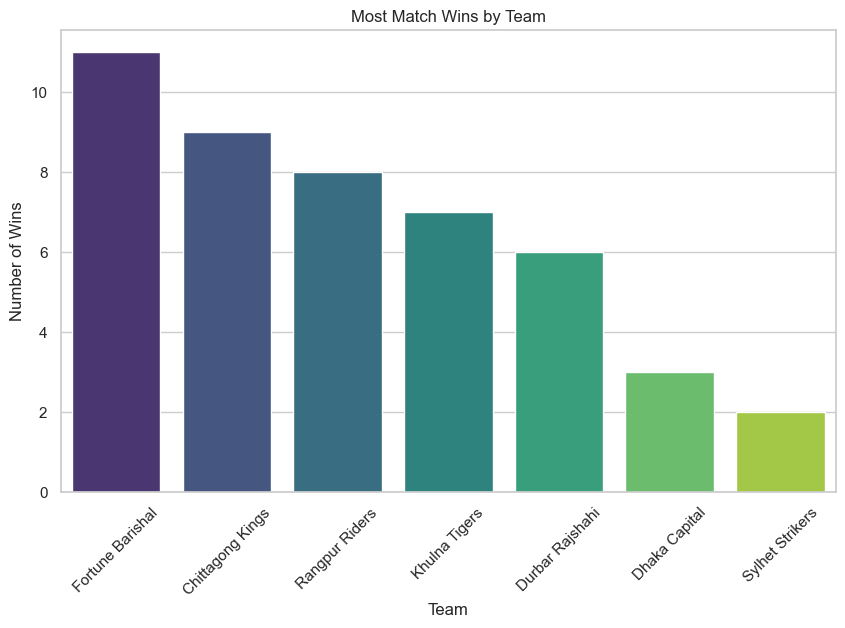

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(data=match_wins_df, x='team', y='match_wins', palette='viridis')
plt.title("Most Match Wins by Team")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)
plt.show()

### Toss Analysis

In [10]:
# Count of toss decisions
toss_decision_counts = df['toss_decision'].value_counts()

**Toss Wins per Team (Count Plot)**

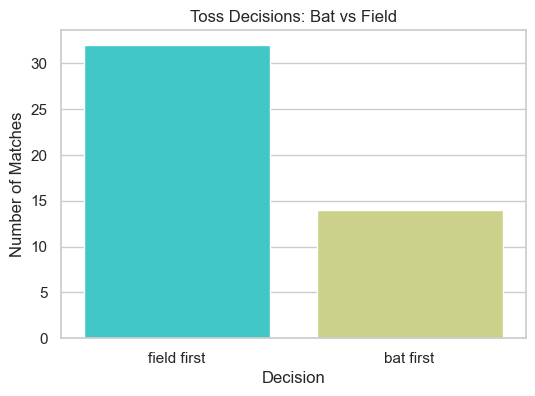

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='toss_decision', data=df, palette='rainbow')
plt.title("Toss Decisions: Bat vs Field")
plt.xlabel("Decision")
plt.ylabel("Number of Matches")
plt.show()

In [12]:
# Total matches
total_matches = df.shape[0]

# Matches where toss winner also won the match
toss_match_wins = df[df['toss_winner'] == df['winner']].shape[0]

# Probability
prob_toss_win_match_win = toss_match_wins / total_matches
print(f"Probability of winning match after winning toss: {prob_toss_win_match_win:.2f}")

Probability of winning match after winning toss: 0.48


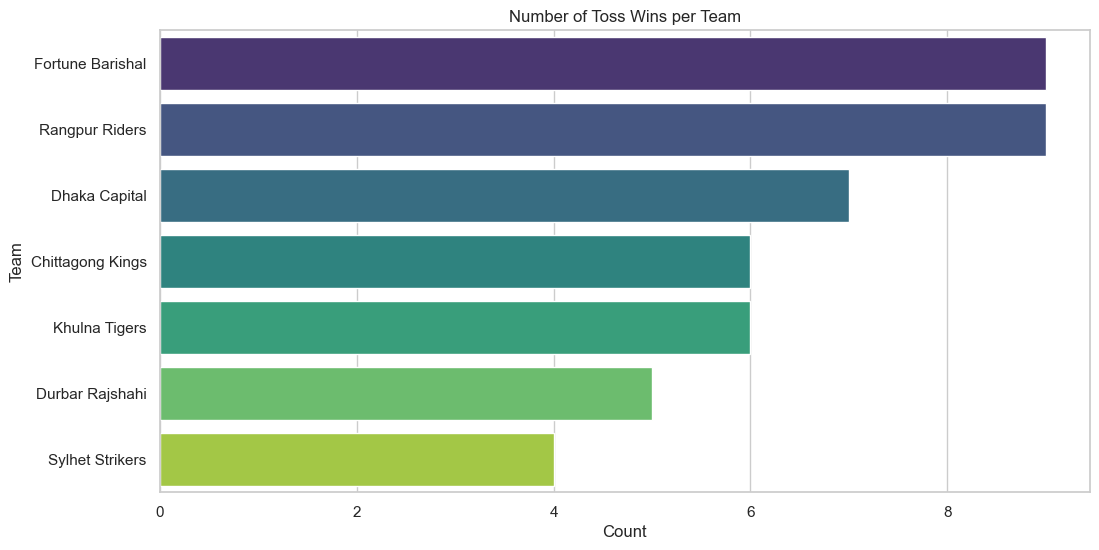

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(y='toss_winner', data=df, order=df['toss_winner'].value_counts().index, palette='viridis')
plt.title("Number of Toss Wins per Team")
plt.xlabel("Count")
plt.ylabel("Team")
plt.show()

In [14]:
# Create a new column: True if toss winner also won the match
df['TossWinnerWonMatch'] = df['toss_winner'] == df['winner']

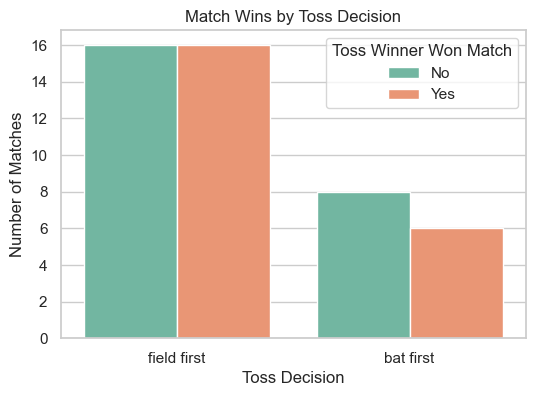

In [15]:
#Plot countplot
plt.figure(figsize=(6,4))
sns.countplot(
    x='toss_decision',
    hue='TossWinnerWonMatch',  # use the new column
    data=df,
    palette='Set2'
)

plt.title("Match Wins by Toss Decision")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.legend(title='Toss Winner Won Match', labels=['No', 'Yes'])
plt.show()

### Performance Analysis

**1.Average, Highest, Lowest Team Scores**

In [16]:
# Combine both teams' scores in one series for analysis
all_scores = pd.concat([df['team_1_score'], df['team_2_score']])

avg_score = all_scores.mean()
highest_score = all_scores.max()
lowest_score = all_scores.min()

print(f"Average Team Score: {avg_score:.2f}")
print(f"Highest Team Score: {highest_score}")
print(f"Lowest Team Score: {lowest_score}")

Average Team Score: 159.21
Highest Team Score: 254
Lowest Team Score: 73


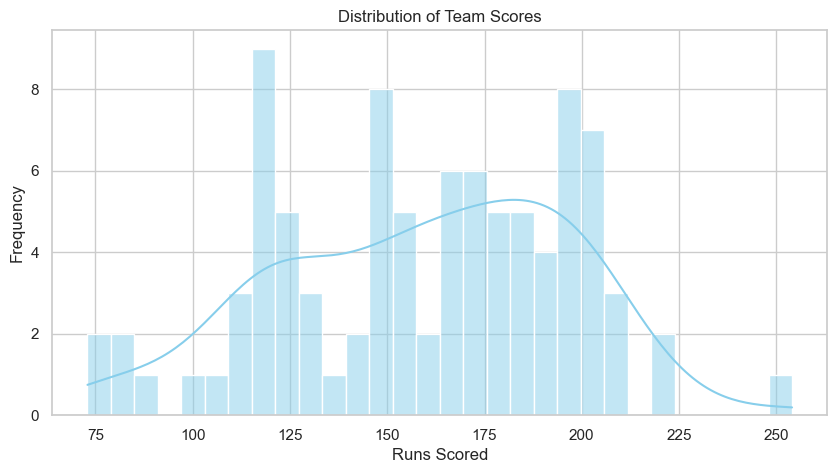

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(all_scores, bins=30, color='skyblue', kde=True)
plt.title("Distribution of Team Scores")
plt.xlabel("Runs Scored")
plt.ylabel("Frequency")
plt.show()

**2.Average Wickets Lost**

In [18]:
# Combine wickets from both teams
all_wickets = pd.concat([df['team_1_wicket'], df['team_2_wicket']])
avg_wickets = all_wickets.mean()

print(f"Average Wickets Lost per Team: {avg_wickets:.2f}")

Average Wickets Lost per Team: 6.50


**3. 200+ Score Count**

In [19]:
num_200_plus = (all_scores >= 200).sum()
print(f"Number of matches where a team scored 200+ runs: {num_200_plus}")

Number of matches where a team scored 200+ runs: 13


**4. Close Match Analysis (win_by_runs < 10)**

In [20]:
close_matches = df[df['win_by_runs'] < 10]
num_close_matches = close_matches.shape[0]

In [21]:
print(f"Number of close matches (won by less than 10 runs): {num_close_matches}")

Number of close matches (won by less than 10 runs): 33


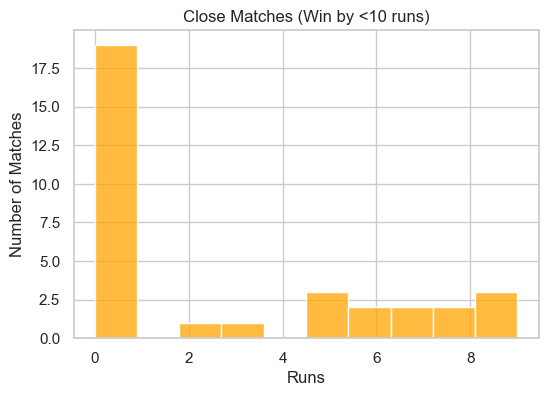

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(close_matches['win_by_runs'], bins=10, color='orange')
plt.title("Close Matches (Win by <10 runs)")
plt.xlabel("Runs")
plt.ylabel("Number of Matches")
plt.show()

###  Win Margin Analysis

**Most Dominant Wins (Largest Mar**

In [23]:
# Largest win by runs
largest_run_win = df['win_by_runs'].max()

# Largest win by wickets
largest_wicket_win = df['win_by_wickets'].max()

In [24]:
print(f"Largest win by runs: {largest_run_win}")
print(f"Largest win by wickets: {largest_wicket_win}")

Largest win by runs: 149
Largest win by wickets: 96


In [25]:
# Close matches: less than 10 runs or less than 3 wickets
close_by_runs = df[df['win_by_runs'] < 10]
close_by_wickets = df[df['win_by_wickets'] < 3]

In [26]:
print(f"Close matches by runs (<10): {close_by_runs.shape[0]}")
print(f"Close matches by wickets (<3): {close_by_wickets.shape[0]}")

Close matches by runs (<10): 33
Close matches by wickets (<3): 28


In [27]:
# Prepare data
close_data = pd.DataFrame({
    'Type': ['Close by Runs', 'Close by Wickets'],
    'Count': [close_by_runs.shape[0], close_by_wickets.shape[0]]
})

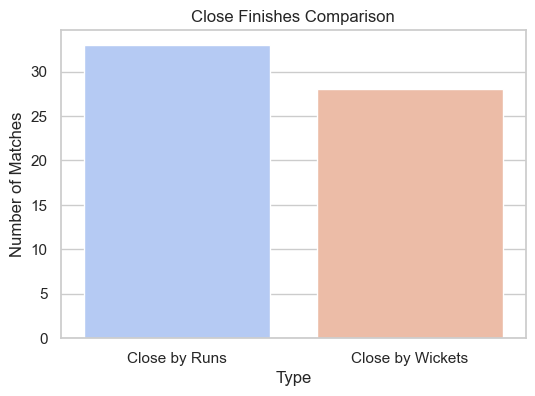

In [28]:
# Plot using barplot
plt.figure(figsize=(6,4))
sns.barplot(x='Type', y='Count', data=close_data, palette='coolwarm')

plt.title("Close Finishes Comparison")
plt.ylabel("Number of Matches")
plt.show()

**Batting First vs Chasing Advantage**

In [29]:
# Batting first wins: win_by_runs > 0
batting_first_wins = df[df['win_by_runs'] > 0].shape[0]

# Chasing wins: win_by_wickets > 0
chasing_wins = df[df['win_by_wickets'] > 0].shape[0]

In [30]:
print(f"Matches won by batting first: {batting_first_wins}")
print(f"Matches won by chasing: {chasing_wins}")

Matches won by batting first: 27
Matches won by chasing: 19


**Wins by Runs vs Wickets**

In [31]:
# Count matches won by runs
wins_by_runs_count = (df['win_by_runs'] > 0).sum()

# Count matches won by wickets
wins_by_wickets_count = (df['win_by_wickets'] > 0).sum()

In [32]:
print(f"Matches won by runs: {wins_by_runs_count}")
print(f"Matches won by wickets: {wins_by_wickets_count}")

Matches won by runs: 27
Matches won by wickets: 19


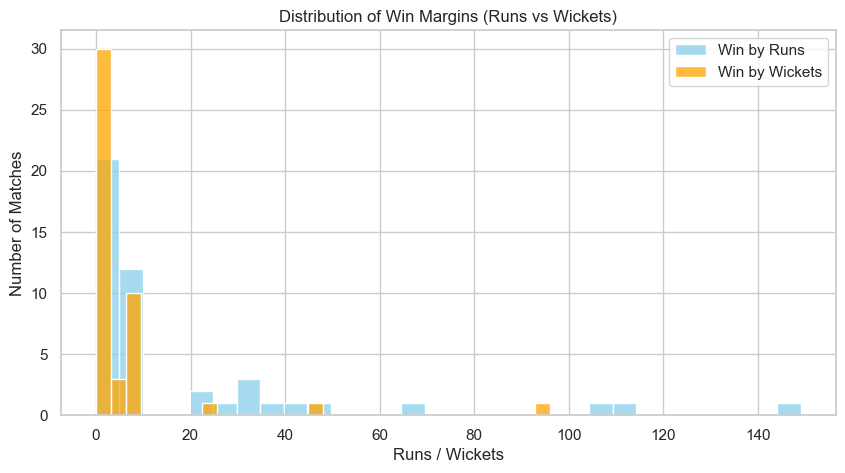

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(df['win_by_runs'], bins=30, color='skyblue', kde=False)
sns.histplot(df['win_by_wickets'], bins=30, color='orange', kde=False)
plt.title("Distribution of Win Margins (Runs vs Wickets)")
plt.xlabel("Runs / Wickets")
plt.ylabel("Number of Matches")
plt.legend(['Win by Runs','Win by Wickets'])
plt.show()

**Most Awarded Player**

In [34]:
# Count total MOM awards per player
mom_counts = df['player_of_match'].value_counts()

# Top 10 players
top_players = mom_counts.head(10)

In [35]:
print("Top 10 Players with Most MOM Awards:")
print(top_players)

Top 10 Players with Most MOM Awards:
player_of_match
Tamim Iqbal            3
Mehidy Hasan Miraz     3
Khushdil Shah          2
Nahid Rana             2
Graham Clark           2
Dawid Malan            2
Zakir Hasan            2
Ryan Burl              2
Mahidul Islam Ankon    1
Mahmudullah            1
Name: count, dtype: int64


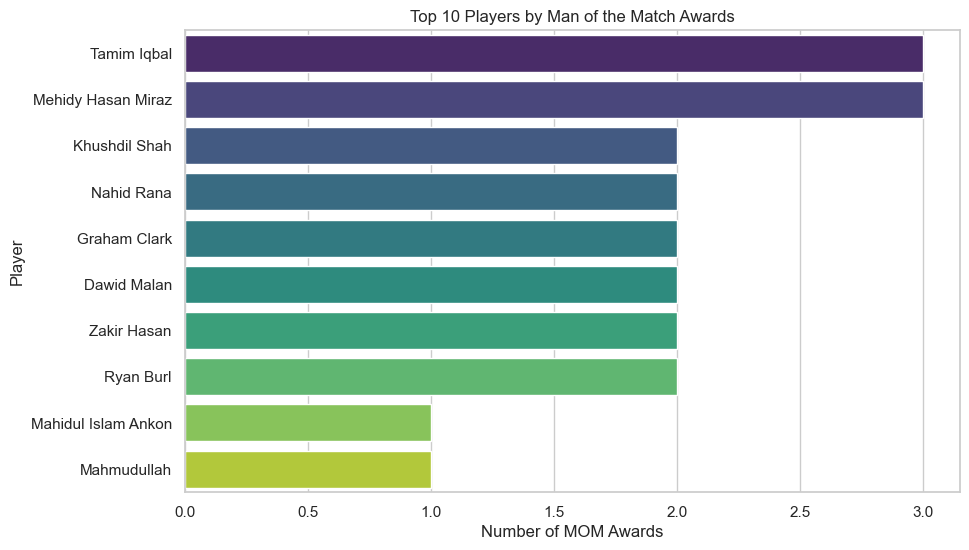

In [36]:
# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=top_players.values, y=top_players.index, palette='viridis')
plt.title("Top 10 Players by Man of the Match Awards")
plt.xlabel("Number of MOM Awards")
plt.ylabel("Player")
plt.show()

### Player of the Match Analysis

**Most awarded player**

In [37]:
# Count MOM awards per player
mom_counts = df['player_of_match'].value_counts()

# Top 10 players
top_players = mom_counts.head(10)

In [38]:
print("Top 10 Players with Most MOM Awards:")
print(top_players)

Top 10 Players with Most MOM Awards:
player_of_match
Tamim Iqbal            3
Mehidy Hasan Miraz     3
Khushdil Shah          2
Nahid Rana             2
Graham Clark           2
Dawid Malan            2
Zakir Hasan            2
Ryan Burl              2
Mahidul Islam Ankon    1
Mahmudullah            1
Name: count, dtype: int64


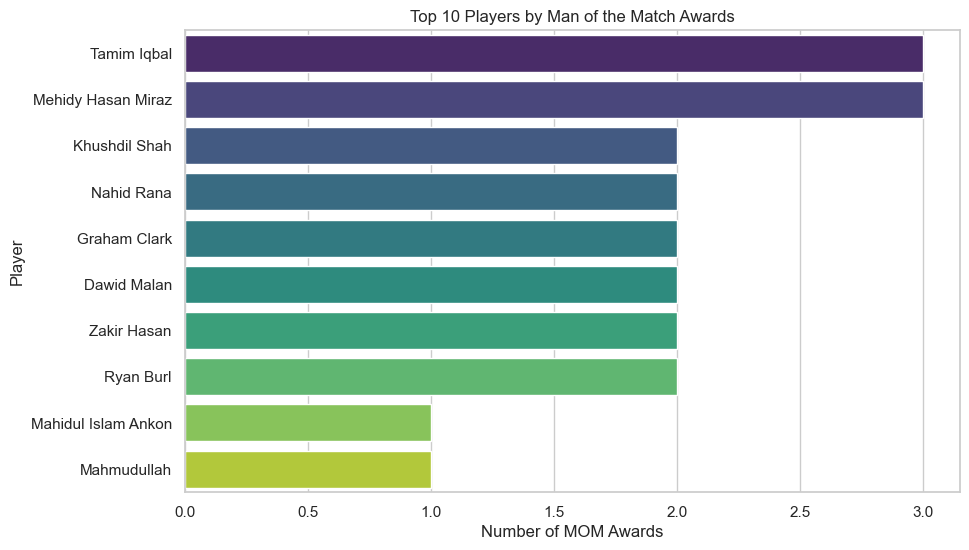

In [39]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_players.values, y=top_players.index, palette='viridis')
plt.title("Top 10 Players by Man of the Match Awards")
plt.xlabel("Number of MOM Awards")
plt.ylabel("Player")
plt.show()

**Season-wise Top Performer**

In [40]:
# Group data by season and calculate top MOM player & their awards
season_top_mom_df = df.groupby('season')['player_of_match'].agg(
   
    # For each season, find the player with the most Man of the Match awards
    Top_Player = lambda x: x.value_counts().idxmax(),
    
    # For each season, find how many awards that player got
    MOM_Awards = lambda x: x.value_counts().max()
).reset_index()  # Convert groupby result into a DataFrame

In [41]:
# Show the results
print("Season-wise Top MOM Player:")
print(season_top_mom_df)

Season-wise Top MOM Player:
    season   Top_Player  MOM_Awards
0  2024/25  Tamim Iqbal           3


###  Venue & City Analysis

- Highest average score by stadium

- City-wise chasing success


**Highest Average Score by Stadium**

In [42]:
# Calculate average team scores per venue
df['team_1_score'] = pd.to_numeric(df['team_1_score'], errors='coerce')
df['team_2_score'] = pd.to_numeric(df['team_2_score'], errors='coerce')

# Average score per match
df['avg_match_score'] = (df['team_1_score'] + df['team_2_score']) / 2

# Average score by venue
venue_avg_score = df.groupby('venue')['avg_match_score'].mean().sort_values(ascending=False)

In [43]:
print("Top 10 Venues by Average Match Score:")
print(venue_avg_score.head(10))

Top 10 Venues by Average Match Score:
venue
SylhetICS    173.083333
ZACS         158.166667
SBNCS        152.204545
Name: avg_match_score, dtype: float64


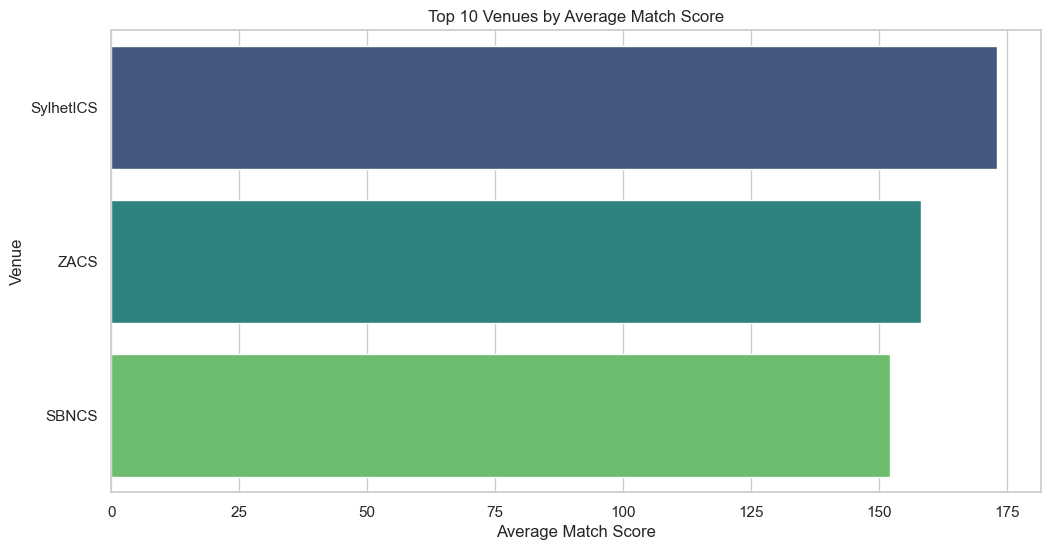

In [44]:
# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=venue_avg_score.head(10).values, y=venue_avg_score.head(10).index, palette='viridis')
plt.title("Top 10 Venues by Average Match Score")
plt.xlabel("Average Match Score")
plt.ylabel("Venue")
plt.show()

In [45]:
# Create a new column to check if the team batting second won
df['batting_second_won'] = df.apply(lambda x: 1 if x['win_by_runs']==0 and x['win_by_wickets']>0 else 0, axis=1)

# Chasing success rate per city
city_chasing = df.groupby('city')['batting_second_won'].mean().sort_values(ascending=False)

In [46]:
print("Top 10 Cities by Chasing Success Rate:")
print(city_chasing.head(10))

Top 10 Cities by Chasing Success Rate:
city
SylhetI       0.583333
Mirpur        0.363636
Chattogram    0.333333
Name: batting_second_won, dtype: float64


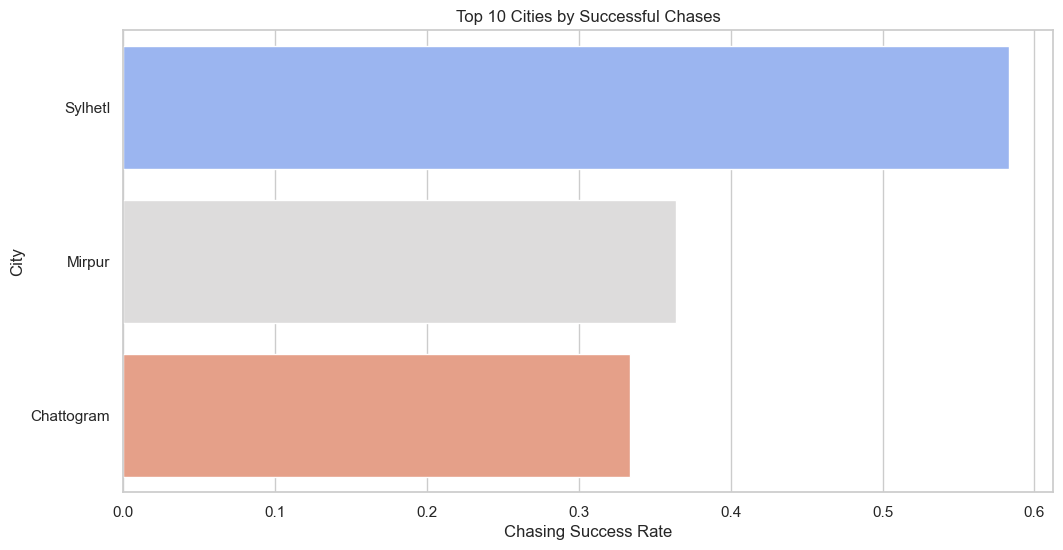

In [47]:
# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=city_chasing.head(10).values, y=city_chasing.head(10).index, palette='coolwarm')
plt.title("Top 10 Cities by Successful Chases")
plt.xlabel("Chasing Success Rate")
plt.ylabel("City")
plt.show()

### Umpire Analysis

**Most Experienced Umpire**

In [48]:
# Combine umpire_1 and umpire_2 into a single series
umpires = pd.concat([df['umpire_1'], df['umpire_2']], axis=0)

# Count total matches per umpire
umpire_counts = umpires.value_counts()

In [49]:
print("Top 10 Umpires by Matches Officiated:")
print(umpire_counts.head(10))

Top 10 Umpires by Matches Officiated:
RR Wimalasiri           15
Asif Yaqoob             14
Gazi Sohel              11
Morshed Ali Khan        11
Masudur Rahman           9
Mahfuzur Rahman          8
Sharfuddoula             7
Tanvir Ahmed             7
Muhammad Kamruzzaman     4
Ali Arman                3
Name: count, dtype: int64


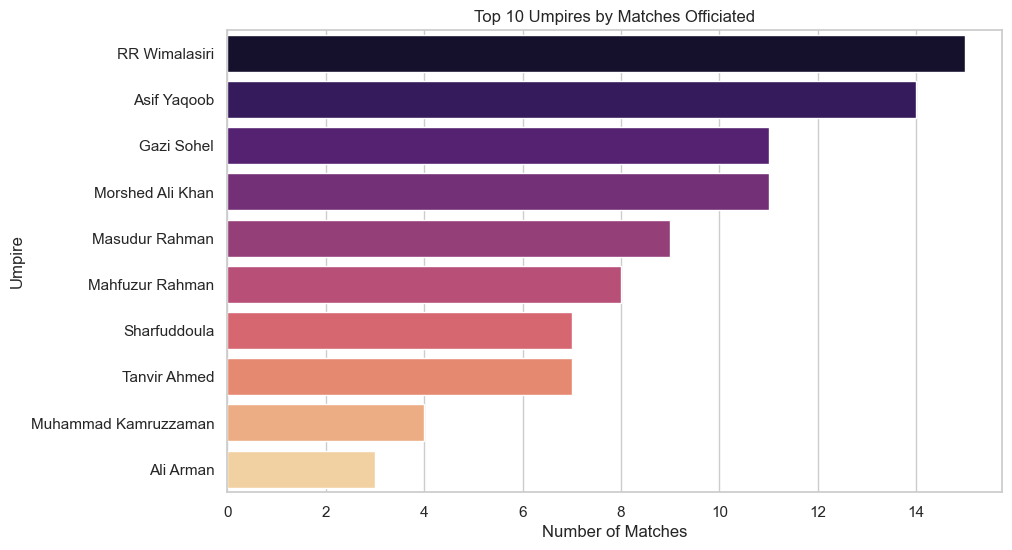

In [50]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=umpire_counts.head(10).values, y=umpire_counts.head(10).index, palette='magma')
plt.title("Top 10 Umpires by Matches Officiated")
plt.xlabel("Number of Matches")
plt.ylabel("Umpire")
plt.show()

**All done! <br>
BPL stats are here – who’s your champion this season?**